# Training Model To Predict Just 1 Feature

In [10]:
import mlflow
import sys
import os

sys.path.append(os.path.abspath(".."))

# --- ENVIRONMENT TOGGLE ---
ENV = 'local' # Kept local for Scout Mode

if ENV == 'local':
    from src import config_local as config
else:
    from src import config_snowflake as config

# Set tracking URI dynamically and create Lite experiment
mlflow.set_tracking_uri(config.MLFLOW_URI)
mlflow.set_experiment("WaterQualityLite")

<Experiment: artifact_location='file:///d:/projects/water-quality-prediction/notebooks/mlruns/2', creation_time=1773241879367, experiment_id='2', last_update_time=1773241879367, lifecycle_stage='active', name='WaterQualityLite', tags={}>

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.base import clone
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, StackingRegressor

warnings.filterwarnings("ignore")

### Load Data & Filter Column

In [12]:
# Dynamically load data based on environment toggle
df = config.load_data()

TARGET_COLS = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
META_COLS = ['Region']

# Unsupervised Pre-Filter
initial_features = [col for col in df.columns if col not in TARGET_COLS + META_COLS]
print(f"Initial features from DE: {len(initial_features)}")

# Variance Check
var_filter = VarianceThreshold(threshold=0.0)
var_filter.fit(df[initial_features].fillna(0))
non_constant_features = [f for f, s in zip(initial_features, var_filter.get_support()) if s]
print(f"Dropped {len(initial_features) - len(non_constant_features)} zero-variance features.")

# Collinearity Check
CORR_THRESHOLD = 0.90 
corr_matrix = df[non_constant_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > CORR_THRESHOLD)]
print(f"Dropped {len(to_drop_corr)} highly correlated features.")

UNIVERSAL_FEATURES = [f for f in non_constant_features if f not in to_drop_corr]
print(f"Final lean feature count ready for baseline training: {len(UNIVERSAL_FEATURES)}")

Initial features from DE: 28
Dropped 7 zero-variance features.
Dropped 2 highly correlated features.
Final lean feature count ready for baseline training: 19


### Configuration

In [ ]:
# --- LITE MODE CONFIGURATION ---
TARGET = 'Electrical Conductance'
HOLDOUT_REGION = 'Eastern_Cape'

print(f"🕵️‍♂️ SCOUT MODE ENGAGED")
print(f"Target: {TARGET} | Holdout: {HOLDOUT_REGION}")

def get_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=False)),
        ('scaler', StandardScaler()),
    ])
    return ColumnTransformer(
        transformers=[('num', numeric_transformer, UNIVERSAL_FEATURES)],
        remainder='drop'
    )

🕵️‍♂️ SCOUT MODE ENGAGED
Target: Total Alkalinity | Holdout: Eastern_Cape


In [14]:
# ==========================================
# Define the Log Transform Wrapper
# ==========================================
def log_wrap(model):
    return TransformedTargetRegressor(
        regressor=model, 
        func=np.log1p, 
        inverse_func=np.expm1
    )

# ==========================================
# Define the Base Models (The "Council")
# ==========================================
ridge_base = Ridge(alpha=10.0) # Bumped alpha for spatial stability
lasso_base = Lasso(alpha=0.001)  # Forces sparse, linear rules

etr_shallow = ExtraTreesRegressor(
    n_estimators=200, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)

xgb_conservative = XGBRegressor(
    n_estimators=300, 
    learning_rate=0.03, 
    max_depth=4,         # Shallow depth to prevent memorization
    subsample=0.7, 
    colsample_bytree=0.6,
    reg_alpha=1.0, 
    reg_lambda=5.0,      # Heavy L1/L2 regularization
    random_state=42, 
    n_jobs=-1
)

base_estimators = [
    ('ridge', ridge_base),
    ('lasso', lasso_base),
    ('etr_shallow', etr_shallow),
    ('xgb_conservative', xgb_conservative)
]

# ==========================================
# Define the Meta-Learner & Build Stack
# ==========================================
meta_learner = KernelRidge(alpha=0.001, kernel='poly', degree=2, coef0=0.5)

stacked_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_learner,
    passthrough=False,  # <-- STRICTLY FALSE: Blocks spatial leakage
    cv=3 
)

# ==========================================
# Final Council (Wrapped and Ready)
# ==========================================
# By wrapping the models HERE, we ensure that even the internal 
# cv=3 loop inside the StackedModel operates safely in log-space!
models = {
    "Ridge_Log": log_wrap(ridge_base),
    "Lasso_Log": log_wrap(lasso_base),
    "XGBoost_Log": log_wrap(xgb_conservative),
    "StackedModel_Log": log_wrap(stacked_model)
}

### Model Training & Evaluation

In [15]:
results = []

# Split Data Geographically
train_df = df[df['Region'] != HOLDOUT_REGION]
test_df = df[df['Region'] == HOLDOUT_REGION]

X_train_raw = train_df[UNIVERSAL_FEATURES]
y_train = train_df[TARGET]
X_test_raw = test_df[UNIVERSAL_FEATURES]
y_test = test_df[TARGET]

# Dynamically fit preprocessor strictly on the training folds
preprocessor = get_preprocessor()
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Training Loop
for model_name, base_model in tqdm(models.items(), desc="Training Models"):
    run_name = f"LITE_{model_name}_{TARGET.replace(' ', '')}"
    
    with mlflow.start_run(run_name=run_name):
        start_time = time.time()
        
        # Train & Predict
        model = clone(base_model)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        run_time = time.time() - start_time
        
        # Scoring
        metrics = {
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "mae": mean_absolute_error(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
            "time_sec": run_time
        }
        
        mlflow.log_param("target", TARGET)
        mlflow.log_param("holdout_region", HOLDOUT_REGION)
        mlflow.log_param("model", model_name)
        mlflow.log_metrics(metrics)
        
        results.append({
            "model": model_name,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"]
        })
        
        tqdm.write(f"✅ {model_name} | R2: {metrics['r2']:.4f} | RMSE: {metrics['rmse']:.4f} | Time: {run_time:.1f}s")

print("\n=== Lite Run Complete! Models logged to MLflow. ===")

Training Models:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Ridge_Log | R2: 0.3074 | RMSE: 61.1502 | Time: 0.0s
✅ Lasso_Log | R2: 0.3084 | RMSE: 61.1089 | Time: 0.0s
✅ XGBoost_Log | R2: 0.1696 | RMSE: 66.9588 | Time: 0.2s
✅ StackedModel_Log | R2: 0.1600 | RMSE: 67.3470 | Time: 6.0s

=== Lite Run Complete! Models logged to MLflow. ===


### Results

In [16]:
results_df = pd.DataFrame(results)

print(f"\n{'='*50}")
print(f"  SCOUT RESULTS: {TARGET}")
print(f"{'='*50}")

# Display a clean, stylized table for the single target
display_df = results_df.set_index("model")
display(display_df.style.highlight_max(subset=['r2'], color="green")
                  .highlight_min(subset=['rmse', 'mae'], color="green")
                  .format("{:.4f}"))


  SCOUT RESULTS: Total Alkalinity


,rmse,mae,r2
model,,,
Ridge_Log,61.1502,47.1472,0.3074
Lasso_Log,61.1089,47.1332,0.3084
XGBoost_Log,66.9588,45.6630,0.1696
StackedModel_Log,67.3470,47.7796,0.1600


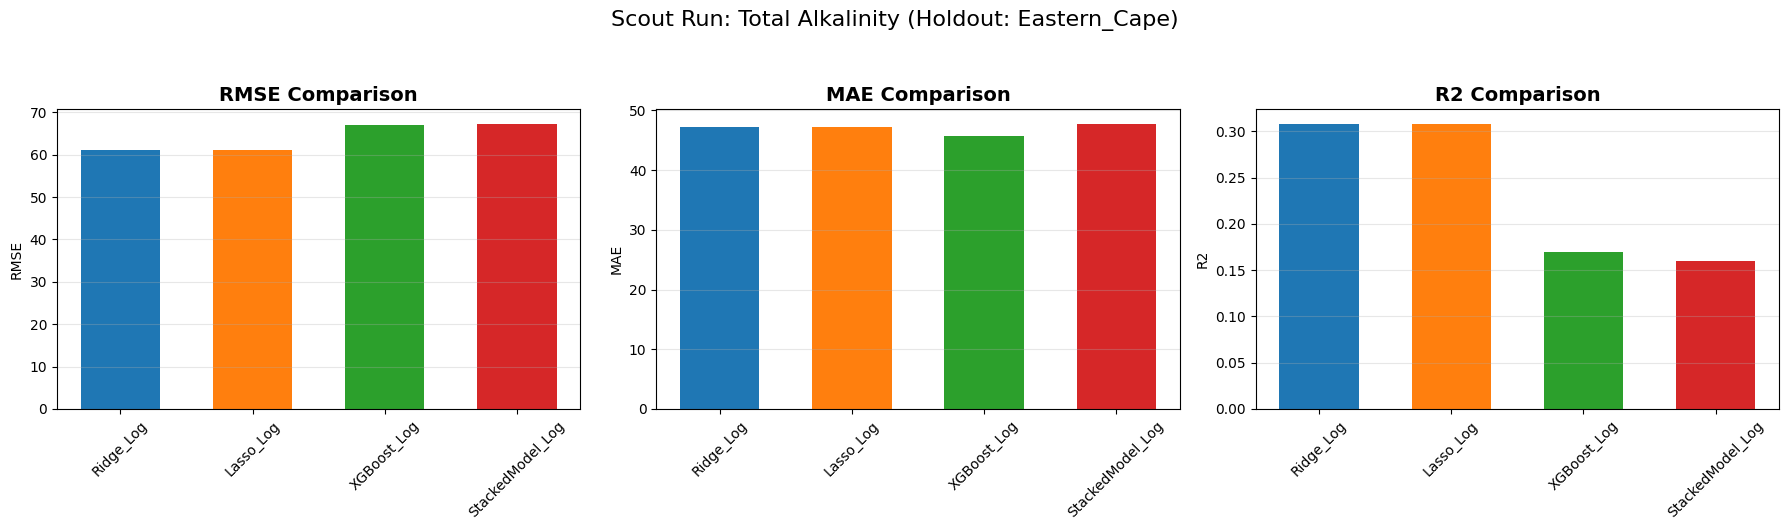


Saved to ../reports/lite_model_comparison.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Using a standard color palette for the 4 models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, metric in zip(axes, ["rmse", "mae", "r2"]):
    ax.bar(results_df["model"], results_df[metric], color=colors, width=0.6)
    
    ax.set_title(f"{metric.upper()} Comparison", fontsize=14, fontweight="bold")
    ax.set_ylabel(metric.upper())
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f"Scout Run: {TARGET} (Holdout: {HOLDOUT_REGION})", y=1.05, fontsize=16)
plt.tight_layout()
plt.savefig("../reports/lite_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved to ../reports/lite_model_comparison.png")